# 03 — Data Perspective

This notebook analyses the data perspective of the student-journey case study. We compare the journeys of students who **graduate on time** and those who **graduate late**. Both come ready from `00_preprocess.ipynb`.

The other notebooks compare the two cohorts through their course (activity) embeddings alone.
This one adds the students' **case attributes**, doc2vec **PV-DM** style: an embedding of the
case's attribute value is *concatenated* into the context vector, so training fits the course
embeddings **and one embedding per attribute value** — again via the **compass method**, which
is what makes a value's two embeddings comparable across the cohorts.

> **One attribute per model.** Two independent attributes in one model share the projection
> layer and their effects mix, so every entry of `ATTRIBUTES` is its own run. Nested attributes
> (the location levels `region`, `city`, `district`) could instead be stacked *as a hierarchy*,
> one embedding per level — the way doc2vec implements a paragraph vector and a document
> vector. This is left for future work.

The notebook runs in three steps:

1. **Train** — load the logs, fit the balanced compass of an attribute on both cohorts
   combined, then one frozen-output model per cohort; each model is cached under
   `results/artefacts`.
2. **Summary** — one table per attribute: every value's cross-cohort cosine and the students
   behind it, plus the same numbers as one long CSV.
3. **Drill-down** — for a single attribute value, the next-block distribution it alone
   predicts, per cohort.

In [4]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from tqdm.auto import tqdm

import log_comparison_block as lcb  # the shared block-structured architecture

SEED = 42
lcb.set_seed(SEED)

# --- folders, anchored on this notebook's own directory
BASE_DIR = Path(lcb.__file__).resolve().parent
LOG_DIR = BASE_DIR / "data" / "preprocessed"
RESULTS_DIR = BASE_DIR / "results"  # the result tables
ARTEFACTS_DIR = RESULTS_DIR / "artefacts"  # the trained models
ARTEFACTS_DIR.mkdir(parents=True, exist_ok=True)

# --- the two cohorts
NAMES = ("on-time", "late")
LOG_PATHS = {n: LOG_DIR / f"students_{n}.csv" for n in NAMES}

# --- architecture and training schedule
C = 2  # context window c, in blocks (= semesters)
EMBEDDING_DIM = 32  # d — course (activity) embeddings
ATTR_DIM = 8  # d_attr  — attribute-VALUE embeddings
UNIT_NORM = True  # keep the embeddings on the unit sphere: every embedding is
# L2-normalised before it enters the context vector, and the read-out is normalised too,
# so a course (or value) is described by its direction alone -- what the cosine reads
LEARNING_RATE_COMPASS, EPOCHS_COMPASS = 1e-2, 1000
LEARNING_RATE, EPOCHS = 1e-2, 1000
DEVICE = "cpu"

# --- the attributes, ONE MODEL PER ENTRY (region/city/district among them, each
#     encoded on its own in the preprocessing like any other attribute)
ATTRIBUTES = [
    "transferred",
    "entry_year",
    "gender",
    "nationality",
    "preference",
    "special_access",
    "admission_type",
    "high_school_graduation_year",
    "high_school_grades",
    "high_school_rank",
    "language_score",
    "math_score",
    "social_sciences_score",
    "natural_sciences_score",
    "high_school_plan_type",
    "high_school_type_program",
    "high_school_type_funding",
    "region",
    "city",
    "district",
]
COLUMN = {a: f"case:{a}" for a in ATTRIBUTES}  # how they are named in the log


# --- where the results go: one file per model, plus the summary table
def model_path(attribute, part):
    return ARTEFACTS_DIR / f"03_data_{attribute}_{part}.pt"


MODEL_PARTS = ("compass", *NAMES)
SUMMARY_PATH = RESULTS_DIR / "03_data_similarity-frequency.csv"

# True retrains every attribute, False reuses the cached models
RECOMPUTE_EMBEDDINGS = False

for n, p in LOG_PATHS.items():
    assert p.exists(), f"log {n!r} not found: {p} — run 00_preprocess.ipynb first"

missing = [
    (a, p) for a in ATTRIBUTES for p in MODEL_PARTS if not model_path(a, p).exists()
]
if not RECOMPUTE_EMBEDDINGS and missing:
    print(
        "missing:",
        *[model_path(a, p).name for a, p in missing[:6]],
        f"... and {len(missing) - 6} more" if len(missing) > 6 else "",
        "set RECOMPUTE_EMBEDDINGS = True to train them",
        sep="\n        ",
    )

## 2. Train the models (compass method)

Both cohorts come ready from `00_preprocess.ipynb`, which also prepared the case attributes:
codes decoded and the numeric attributes cut into quantile bins over all students. The three
location levels are encoded separately, like every other categorical attribute. They ride along
on the `case:` columns, one constant value per case.

A student without a value for an attribute keeps their courses in the training; the attribute
simply takes its **missing** token, whose embedding is the fixed zero vector, so it says
nothing about that case. It has no embedding to compare, so it carries no cosine — the summary
tables list it as `unknown`, with the students behind it but `n.a.` for a similarity.

One **compass** model per attribute, fitted on both cohorts combined, fixes the shared output
matrix $\mathbf{E}_{\mathrm{out}}$; each cohort is then retrained from the compass with that
output **frozen**, so only its input embeddings move — courses *and* attribute values, against
one and the same output space.

`balance_compass=True` rescales the smaller cohort's case counts so both logs weigh equally in
the compass loss. Every attribute is an independent run: its own compass, its own vocabulary of
attribute values, its own pair of models — the three location levels are three such runs. The
models are cached individually. If `RECOMPUTE_EMBEDDINGS = False`, they are loaded instead of
retrained.

In [5]:
logs = {n: pd.read_csv(p) for n, p in LOG_PATHS.items()}

# one row per student, for the value counts in the summary
students = {
    n: df.drop_duplicates("case:concept:name").set_index("case:concept:name")
    for n, df in logs.items()
}

In [6]:
def train_attribute(attribute):
    """The three models of one attribute: compass, on-time, late."""
    model_i, model_j, compass = lcb.compare_block_event_logs_pvdm(
        logs[NAMES[0]],
        logs[NAMES[1]],
        COLUMN[attribute],
        names=NAMES,
        c=C,
        embedding_dim=EMBEDDING_DIM,
        attr_dim=ATTR_DIM,
        compass_learning_rate=LEARNING_RATE_COMPASS,
        compass_epochs=EPOCHS_COMPASS,
        log_learning_rate=LEARNING_RATE,
        log_epochs=EPOCHS,
        unit_norm=UNIT_NORM,
        balance_compass=True,
        device=DEVICE,
        verbose=True,
    )
    return {"compass": compass, NAMES[0]: model_i, NAMES[1]: model_j}


models = {}
progress = tqdm(ATTRIBUTES, desc="trained" if RECOMPUTE_EMBEDDINGS else "loaded")
for attribute in progress:
    progress.set_postfix_str(attribute)
    if RECOMPUTE_EMBEDDINGS:
        models[attribute] = train_attribute(attribute)
        for part, model in models[attribute].items():
            lcb.save_model(model, model_path(attribute, part))
    else:
        models[attribute] = {
            part: lcb.load_model(model_path(attribute, part), device=DEVICE)
            for part in MODEL_PARTS
        }

loaded:   0%|          | 0/20 [00:00<?, ?it/s]

## 3. Summary

**One table per attribute**: one row per value, carrying the **cross-cohort cosine similarity**
of its embedding — on-time against late, in the shared compass space — and the number of
**students** behind it in each cohort. The similarity is colour-coded over the full cosine
range, red (`-1`, the value sits in different behaviour in the two cohorts) through yellow
(`0`) to green (`+1`, the same behaviour).

Two reading caveats:

- a **frequency of 0**, marked red, means the value is carried by students of one cohort only.
  It receives no gradient in the other, where its embedding stays at the compass value — its
  cosine measures the compass, not a shift;
- values behind a handful of students are fitted on very little data, so read them as a
  tendency rather than an estimate.

The same numbers go to `03_data_similarity-frequency.csv`.

In [7]:
BIN_LABELS = [
    "low",
    "medium",
    "high",
]  # quantile bins keep THEIR order, not the alphabet
UNKNOWN_LABEL = "unknown"  # how the students without a value are listed


def value_of(token):
    """`case:gender=2` -> `2` — the value without its attribute prefix."""
    return token.split("=", 1)[-1]


def sort_key(value):
    return (BIN_LABELS.index(value) if value in BIN_LABELS else -1, str(value))


def attribute_table(attribute):
    """One attribute as a frame: a row per value, with its cross-cohort cosine and
    the students carrying it in each cohort. The students *without* a value close the
    table: their token is the fixed zero embedding, so they have a frequency but no
    cosine."""
    sims = lcb.attribute_similarity(
        models[attribute][NAMES[0]], models[attribute][NAMES[1]]
    )
    sims = {value_of(t): float(v) for t, v in sims.items()}
    # counted through the same renderer the model tokens use, so `1.0` in the
    # CSV and the token `preference=1` are the one value they are
    counts = {
        n: s[COLUMN[attribute]].map(lcb._fmt_attr_value).value_counts().to_dict()
        for n, s in students.items()
    }
    rows = [
        {
            "value": v,
            "sim": sims[v],
            **{f"freq {n}": counts[n].get(v, 0) for n in NAMES},
        }
        for v in sorted(sims, key=sort_key)
    ]
    # the missing value is row 0 of E_in', held at zero and never fitted, so it is
    # absent from the similarity — it is listed last, on its student counts alone
    unknown = {n: counts[n].get(lcb.MISSING_VALUE, 0) for n in NAMES}
    if any(unknown.values()):
        rows.append(
            {
                "value": UNKNOWN_LABEL,
                "sim": np.nan,
                **{f"freq {n}": unknown[n] for n in NAMES},
            }
        )
    return pd.DataFrame(rows, columns=["value", "sim", *[f"freq {n}" for n in NAMES]])


def style_table(table, caption):
    """The cosine colour-coded over the full range, red (-1) to green (+1); a value
    carried by no student of a cohort has that frequency in red, its cosine measuring
    the compass rather than a shift."""
    return (
        table.style.format(
            {"sim": "{:+.3f}", **{f"freq {n}": "{:,.0f}" for n in NAMES}},
            na_rep="n.a.",  # the unknown row, which has no embedding to compare
        )
        .background_gradient(subset=["sim"], cmap="RdYlGn", vmin=-1, vmax=1)
        # the gradient paints a missing cosine solid black -- keep `n.a.` plain
        .map(
            lambda v: (
                "background-color: transparent; color: inherit" if pd.isna(v) else ""
            ),
            subset=["sim"],
        )
        .map(
            lambda v: "color: #d62728" if v == 0 else "",
            subset=[f"freq {n}" for n in NAMES],
        )
        .set_properties(subset=["value"], **{"text-align": "left"})
        .set_caption(caption)
        .hide(axis="index")
    )


tables = {a: attribute_table(a) for a in ATTRIBUTES}
for attribute, table in tables.items():
    display(style_table(table, attribute))

summary = pd.concat(
    [t.assign(attribute=a) for a, t in tables.items()], ignore_index=True
).rename(columns={"sim": "cosine_similarity"})[
    ["attribute", "value", "cosine_similarity", *[f"freq {n}" for n in NAMES]]
]
summary.to_csv(SUMMARY_PATH, index=False)

value,sim,freq on-time,freq late
no,+0.730,26,87
yes,+0.821,1,33


value,sim,freq on-time,freq late
2012,+0.718,2,6
2013,+0.782,4,12
2014,+0.766,3,14
2015,+0.824,6,22
2016,+0.798,4,24
2017,+0.993,0,21
2018,+0.856,5,17
2019,+0.783,3,4


value,sim,freq on-time,freq late
1,+0.876,5,16
2,+0.799,22,104


value,sim,freq on-time,freq late
chilean,+0.232,17,38
unknown,n.a.,10,82


value,sim,freq on-time,freq late
1,+0.441,10,23
2,+0.551,3,9
3,+0.619,2,3
4,+0.405,2,2
5,+0.996,0,1
unknown,n.a.,10,82


...

value,sim,freq on-time,freq late
0,+0.575,15,32
4,+0.957,1,0
5,+0.323,1,5
7,+0.993,0,1
unknown,n.a.,10,82


value,sim,freq on-time,freq late
2,+0.711,2,4
3,+0.377,13,26
4,+0.500,2,8
unknown,n.a.,10,82


value,sim,freq on-time,freq late
13,+0.165,15,36
5,+0.678,1,1
6,+0.789,1,1
unknown,n.a.,10,82


value,sim,freq on-time,freq late
100,+0.997,0,2
114,+0.913,11,24
124,+0.992,0,1
126,+0.992,0,1
135,+0.993,0,1
36,+0.994,0,1
5,+0.995,0,1
57,+0.997,0,1
62,+0.992,0,1
66,+0.942,1,0


value,sim,freq on-time,freq late
102,+0.670,4,3
103,+0.992,0,1
105,+0.998,0,2
106,+0.989,0,1
107,+0.999,0,2
109,+0.976,1,0
112,+0.996,0,1
113,+0.991,0,1
14,+0.996,0,1
19,+0.924,1,0


## 4. Drill-down: what one attribute value alone predicts

Pick an attribute and one of its values, and read the **next-block distribution attributable to
that value**: the value's embedding goes through the frozen output matrix and the softmax with
the **course context held at zero**, so the bars show the pull of the value *itself*, not of the
courses its students happened to take. One bar colour per cohort, so a value that means
different things in the two cohorts shows up as two different shapes.

The bars are a *conditional* statement — probabilities over the next block given nothing but the
value — so they do not match how often those courses actually occur.

`E_out` carries a **bias** as well as the matrix — one learned offset per target, added to every
logit whatever the context — so it encodes how often a target occurs, not what *this* token
pulls towards. In a real context `h` is the sum of a whole semester's embeddings and the bias is
a modest correction; in this drill-down `h` holds a single unit vector, and the bias outweighs
it. `DRILL_INCLUDE_BIAS = False` therefore scores the context with the matrix alone, which is
the token's own pull; set it to `True` to read the model's actual predictive distribution.


In [10]:
DRILL_ATTRIBUTE = "high_school_grades"  # an entry of ATTRIBUTES
DRILL_VALUE = "medium"  # one of its values
DRILL_TOP_K = 10  # next-block tokens shown
DRILL_INCLUDE_BIAS = False  # score with E_out's bias too? see the note above

DRILL_COLOR = {"on-time": "#0098A1", "late": "#E8833A"}

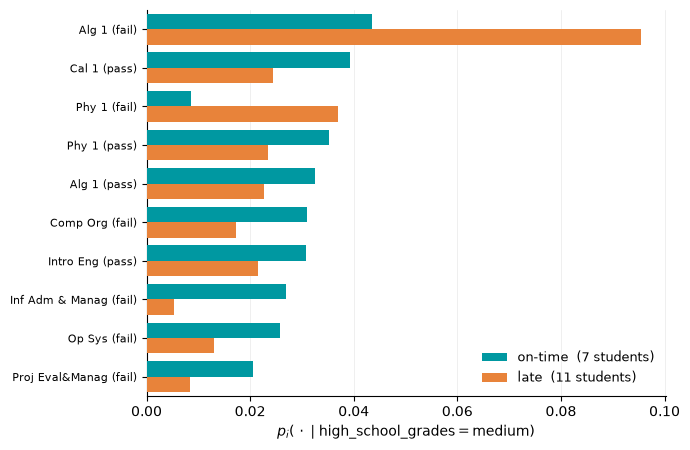

In [12]:
def value_next_distribution(model, value, include_bias=True):
    """The next-block distribution attributable to one attribute VALUE: its
    embedding alone in the context vector, the c course blocks held at zero.

    Returns a Series over the candidate targets Act(L) u {#END#} — the columns of
    E_out, indexed by ``word_to_ix[token] - lcb.TARGET_OFFSET``.

    :param include_bias: score with E_out's bias as well as its matrix. ``False``
        drops the bias, leaving the token's own pull (see the note above).
    """
    token = f"{model.attr_name}={value}"
    if token not in model.attr_value_to_ix:
        raise KeyError(
            f"{value!r} is not a value of {model.attr_name!r}; these are: "
            f"{[value_of(t) for t in model.attr_value_to_ix]}"
        )
    device = model.output.weight.device
    h = torch.zeros(1, model.output.in_features, device=device)
    with torch.no_grad():
        ix = model.attr_value_to_ix[token]
        emb = model.attr_embeddings.weight[ix]
        if model.unit_norm:
            # the forward pass normalises emb(g), so h must be built the same way
            emb = torch.nn.functional.normalize(emb, p=2, dim=0)
        h[0, C * EMBEDDING_DIM :] = emb
        # E_out's bias is one offset per target, added whatever the context, so it
        # says how often a target occurs rather than what THIS token pulls towards.
        # With a single embedding in h it outweighs the token, so the read-out drops
        # it by default and scores the context with the matrix alone.
        logits = model.output(h) if include_bias else h @ model.output.weight.T
        p = torch.softmax(logits, dim=1)[0].cpu()
    targets = [t for t in model.word_to_ix if t != lcb.START_TOKEN]
    return pd.Series(
        {t: float(p[model.word_to_ix[t] - lcb.TARGET_OFFSET]) for t in targets}
    )


dmap = {
    n: value_next_distribution(
        models[DRILL_ATTRIBUTE][n], DRILL_VALUE, include_bias=DRILL_INCLUDE_BIAS
    )
    for n in NAMES
}
p = pd.DataFrame(dmap)
p["difference"] = (p[NAMES[0]] - p[NAMES[1]]).abs()

# the tokens the two cohorts disagree on most, drawn by size
tokens = list(
    p.loc[p["difference"].nlargest(DRILL_TOP_K).index, list(NAMES)]
    .max(axis=1)
    .sort_values(ascending=False)
    .index
)

y = np.arange(len(tokens))
bh = 0.8 / len(NAMES)

fig, ax = plt.subplots(figsize=(7.0, max(3.0, 0.46 * len(tokens))))
ax.set_axisbelow(True)
ax.xaxis.grid(True, linewidth=0.4, alpha=0.35)
for ei, n in enumerate(NAMES):
    n_students = int(
        (
            students[n][COLUMN[DRILL_ATTRIBUTE]].map(lcb._fmt_attr_value) == DRILL_VALUE
        ).sum()
    )
    ax.barh(
        y + (ei - (len(NAMES) - 1) / 2) * bh,
        [dmap[n][t] for t in tokens],
        height=bh,
        color=DRILL_COLOR[n],
        zorder=3,
        label=f"{n}  ({n_students} students)",
    )

ax.set_yticks(y)
ax.set_yticklabels(["(end)" if t == lcb.END_TOKEN else t for t in tokens], fontsize=8)
ax.set_ylim(len(tokens) - 0.5, -0.5)  # the strongest pull at the top
# only the token is escaped -- escaping the whole label would eat the subscript of p_i
drill_label = f"{DRILL_ATTRIBUTE}={DRILL_VALUE}".replace("_", r"\_").replace(" ", r"\ ")
ax.set_xlabel(rf"$p_i(\,\cdot \mid \mathrm{{{drill_label}}})$")
ax.legend(frameon=False, fontsize=9, loc="lower right")
for side in ("top", "right"):
    ax.spines[side].set_visible(False)
fig.tight_layout()
plt.show()